# Credit Risk Analysis
## Goal: To predict which loan applicants are likely to default

#### Business problem:
A bank wants to identify high-risk borrowers before approving loans. We will analyze 150,000 loan applicants and build a model to predict default risk.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/credit-training.csv")

In [3]:
df.shape

(150000, 12)

In [4]:
df.columns.tolist()

['Unnamed: 0',
 'SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [5]:
df['Unnamed: 0'].head(10)

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: Unnamed: 0, dtype: int64

In [6]:
df = df.drop(columns=['Unnamed: 0'])

In [7]:
df.shape

(150000, 11)

In [8]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

### Missing values found
- Monthly Income: 29,731 missing (19.8% of data)
- NumberOfDependents: 3924 missing (2.6% of data)

Possible reasons for missing MonthlyIncome: self-employed, retired, or refused to disclose.
we will handle these in the data cleaning phase.

In [10]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [11]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


# Describing the findings

When looking at the max values:
- NumberOfTimes90DaysLate = 98, means 98 times late on payments. That's being late every month for 8 years straight. Almost certainly a data entry error or outlier.
- RevolvingUtilizationOfUnsecuredLines = 50708, this is the ratio (how much credit limit are you using? a ratio should be between 0 and 1. Someone using 50,708% of their credit limit is impossible. This is a dirty data problem.)
- This is called outlier detection.

In [13]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

### Insight:

This is a problem. And an important one.
Think about it — if our ML model is lazy and just predicts "nobody defaults" for everyone, it would be 93.3% accurate. Sounds great right?
But it would miss every single actual defaulter. Completely useless for a bank.
This is called a Class Imbalance problem. We'll deal with it in the ML phase. But spotting it now — during EDA — means we won't be surprised later.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


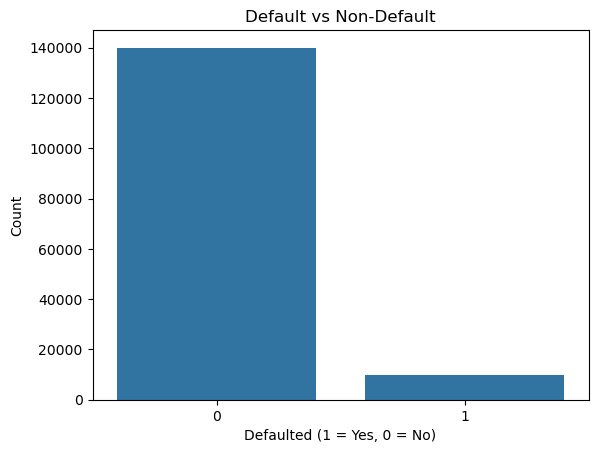

In [15]:
sns.countplot(x='SeriousDlqin2yrs', data =df)
plt.title('Default vs Non-Default')
plt.xlabel('Defaulted (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()


##### from the above figure, we can see that default value = 1 is significantly less than default value = 0.

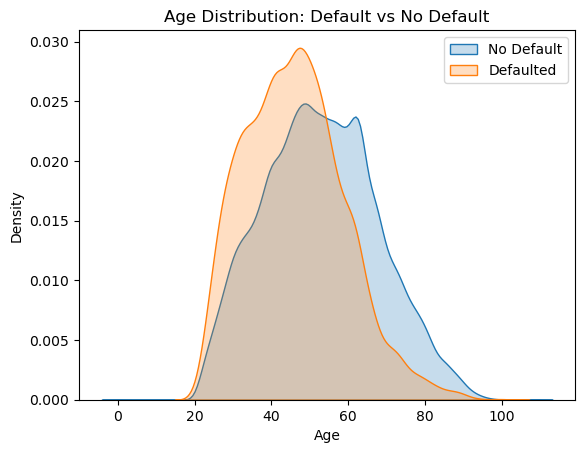

In [17]:
sns.kdeplot(data=df[df['SeriousDlqin2yrs']==0]['age'], label='No Default', fill=True)
sns.kdeplot(data=df[df['SeriousDlqin2yrs']==1]['age'], label='Defaulted', fill=True)
plt.title('Age Distribution: Default vs No Default')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

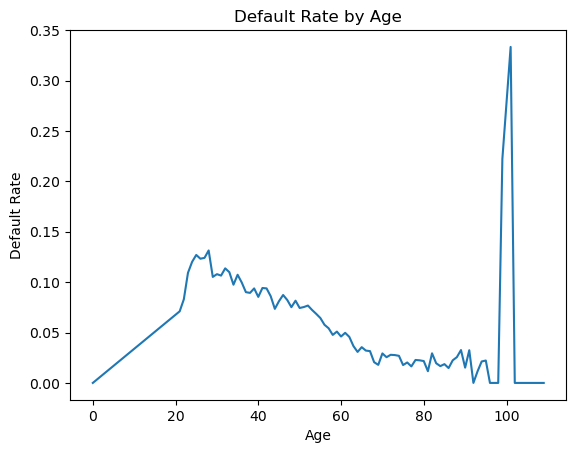

In [18]:
df.groupby('age')['SeriousDlqin2yrs'].mean().plot()
plt.title('Default Rate by Age')
plt.xlabel('Age')
plt.ylabel('Default Rate')
plt.show()

### age vs default rate:
- visualization created but needs further interpretation
- to revisit: understand  KDE plots and density

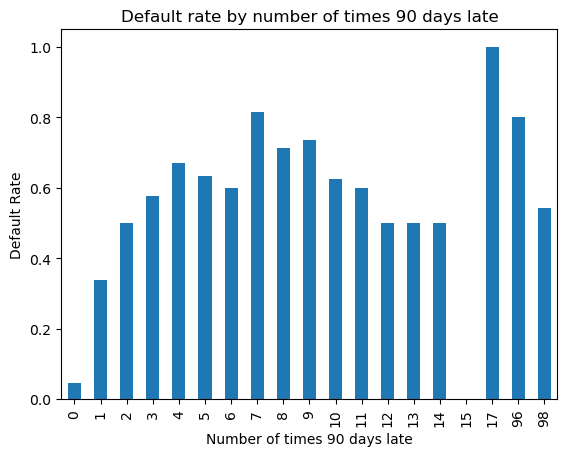

In [20]:
df.groupby('NumberOfTimes90DaysLate')['SeriousDlqin2yrs'].mean().plot(kind='bar')
plt.title('Default rate by number of times 90 days late')
plt.xlabel('Number of times 90 days late')
plt.ylabel('Default Rate')
plt.show()